<a href="https://colab.research.google.com/github/ValentinaEmili/Texture-synthesis/blob/main/training/training_TT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [22]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
!pip install lpips

In [3]:
import os
from PIL import Image
import torchvision.transforms as transforms
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn
import torch.nn.functional as F
import torch
import torch.optim as optim
from torchvision.models import vgg16
import matplotlib.pyplot as plt
import time
import lpips
import sys

In [4]:
REPO_DIR = '/content/Texture_synthesis'
os.chdir('/content')

if not os.path.exists(REPO_DIR):
  !git clone https://github.com/ValentinaEmili/Texture-synthesis.git Texture_synthesis

if REPO_DIR not in sys.path:
  sys.path.append(REPO_DIR)

Cloning into 'Texture_synthesis'...
remote: Enumerating objects: 189, done.
remote: Counting objects: 100% (189/189), done.
remote: Compressing objects: 100% (180/180), done.
remote: Total 189 (delta 86), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (189/189), 17.69 MiB | 7.59 MiB/s, done.
Resolving deltas: 100% (86/86), done.


In [5]:
!pip install import-ipynb -q
import import_ipynb
from Texture_synthesis.codebook.VQGAN.VQGAN_TT import VQGAN, Discriminator

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 83.1 MB/s eta 0:00:00


In [6]:
train_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.RandomCrop(256),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])

eval_transform = transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(256),
        transforms.ToTensor(),
        transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5))
        ])


class DTD_Dataset(Dataset):
    def __init__(self, root, file_list, transform=None, class_to_idx=None):
        self.root = root
        self.transform = transform

        with open(file_list, mode='r', encoding='utf-8') as f:
            self.files = [line.strip() for line in f if line.strip()]

        if class_to_idx is None:
          unique_classes = sorted({os.path.normpath(p).split(os.sep)[0] for p in self.files})
          self.class_to_idx = {class_name: i for i, class_name in enumerate(unique_classes)}
        else:
          self.class_to_idx = class_to_idx

    def __len__(self):
        return len(self.files)

    def __getitem__(self, idx):
        relative_path = self.files[idx]
        image_path = os.path.join(self.root, relative_path)
        img = Image.open(image_path).convert('RGB')
        rel_norm = os.path.normpath(relative_path)
        string_label = rel_norm.split(os.sep, 1)[0]
        label = self.class_to_idx[string_label]

        if self.transform:
            img = self.transform(img)

        return img, label

In [7]:
path_images = "drive/MyDrive/DeepLearning/dtd/images"
path_labels = "drive/MyDrive/DeepLearning/dtd/labels"
train_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "train1.txt"), train_transform)
class_to_idx = train_dataset.class_to_idx
val_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "val1.txt"), eval_transform, class_to_idx=class_to_idx)
test_dataset = DTD_Dataset(path_images, os.path.join(path_labels, "test1.txt"), eval_transform, class_to_idx=class_to_idx)

train_loader = DataLoader(train_dataset, batch_size=4, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=4, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=4, shuffle=False, num_workers=2)

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
generator = VQGAN().to(device)
discriminator = Discriminator().to(device)
optimizer_generator = optim.Adam(generator.parameters(), lr=2e-4, betas=(0.5, 0.9))
optimizer_discriminator = optim.Adam(discriminator.parameters(), lr=5e-5, betas=(0.5, 0.9))
perceptual_loss_fn = lpips.LPIPS(net='vgg').to(device)

Setting up [LPIPS] perceptual loss: trunk [vgg], v[0.1], spatial [off]


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=VGG16_Weights.IMAGENET1K_V1`. You can also use `weights=VGG16_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:05<00:00, 96.6MB/s]


Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/vgg.pth


## Training

In [ ]:
def calculate_adaptive_weight(recon_loss, g_loss, last_layer_weights):
    recon_grads = torch.autograd.grad(recon_loss, last_layer_weights, retain_graph=True, allow_unused=True)[0]
    g_grads = torch.autograd.grad(g_loss, last_layer_weights, retain_graph=True, allow_unused=True)[0]

    if recon_grads is None:
      recon_norm = torch.tensor(0., device=last_layer_weights.device)
    else:
      recon_norm = torch.norm(recon_grads)

    if g_grads is None:
      g_norm = torch.tensor(0., device=last_layer_weights.device)
    else:
      g_norm = torch.norm(g_grads)

    lambda_weight = recon_norm / (g_norm + 1e-4)
    lambda_weight = torch.clamp(lambda_weight, 0.0, 1e4).detach()
    return lambda_weight

In [ ]:
def set_requires_grad(model, requires_grad):
  for param in model.parameters():
    param.requires_grad = requires_grad

def train_step(generator, discriminator, perceptual_loss_fn, data, optimizer_g, optimizer_d, disc_start_step, current_global_step):
    # GENERATOR

    # disable discriminator gradients while training generator
    set_requires_grad(discriminator, False)

    optimizer_g.zero_grad()
    recon_batch, vq_loss, perplexity, active_codes = generator(data)
    recon_loss = F.mse_loss(recon_batch, data)
    percept_loss = perceptual_loss_fn(recon_batch, data).mean()

    # dynamic adaptive weight scheduling
    if current_global_step >= disc_start_step:
        fake_outputs = discriminator(recon_batch)
        g_loss = -fake_outputs.mean()   # hinge loss

        last_layer_weights = generator.decoder.conv_out.weight
        #last_layer_weights = generator.decoder.conv3.weight
        disc_weight = calculate_adaptive_weight(recon_loss + percept_loss, g_loss, last_layer_weights)

        total_g_loss = vq_loss + recon_loss + percept_loss + (disc_weight * g_loss)
    else:
        total_g_loss = vq_loss + recon_loss + percept_loss

    total_g_loss.backward()
    optimizer_g.step()
    set_requires_grad(discriminator, True)

    # DISCRIMINATOR
    total_d_loss = torch.tensor(0.0, device=data.device)
    if current_global_step >= disc_start_step:
        optimizer_d.zero_grad()

        real_outputs = discriminator(data)
        fake_outputs_d = discriminator(recon_batch.detach())

        loss_real = F.relu(1.0 - real_outputs).mean()
        loss_fake = F.relu(1.0 + fake_outputs_d).mean()

        total_d_loss = 0.5 * loss_real + 0.5 * loss_fake
        total_d_loss.backward()
        optimizer_d.step()

    return total_g_loss.item(), total_d_loss.item(), perplexity.item(), active_codes

In [ ]:
global_step = 0
disc_start_step = 1000
epochs = 20

save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers'

best_val_score = float('inf')

for epoch in range(epochs):
    generator.train()
    discriminator.train()
    epoch_start = time.time()

    total_loss_generator = 0.0
    perplexity_generator, avg_active_codes_generator = 0.0, 0.0
    total_loss_discriminator = 0.0

    # training
    for batch_idx, (data, _) in enumerate(train_loader):
        data = data.to(device)
        g_loss_val, d_loss_val, epoch_g_perplexity, epoch_g_active_codes = train_step(
            generator, discriminator, perceptual_loss_fn, data,
            optimizer_generator, optimizer_discriminator,
            disc_start_step, global_step)

        global_step += 1
        total_loss_generator += g_loss_val
        total_loss_discriminator += d_loss_val
        perplexity_generator += epoch_g_perplexity
        avg_active_codes_generator += epoch_g_active_codes

    avg_g_loss = total_loss_generator / len(train_loader)
    avg_d_loss = total_loss_discriminator / len(train_loader)
    print(f"====> Epoch {epoch} Finished | Avg G-Loss: {avg_g_loss:.4f} | Avg D-Loss: {avg_d_loss:.4f}")
    print(f"      Generator ========> Average Loss:{avg_g_loss:.4f} | Perplexity: {perplexity_generator/len(train_loader):.2f} | Active codes: {avg_active_codes_generator/len(train_loader):.2f}")
    print(f"      Discriminator ====> Average Loss:{avg_d_loss:.4f}\n")
    epoch_save_path = os.path.join(save_path, f"epoch_{epoch}")

    # save generator model at each epoch
    gen_path = os.path.join(epoch_save_path, "generator")
    os.makedirs(gen_path, exist_ok=True)

    torch.save(generator.state_dict(), os.path.join(gen_path, "main_model.pth"))
    torch.save(optimizer_generator.state_dict(), os.path.join(gen_path, "optimizer.pth"))

    # save discriminator model at each epoch
    disc_path = os.path.join(epoch_save_path, "discriminator")
    os.makedirs(disc_path, exist_ok=True)

    torch.save(discriminator.state_dict(), os.path.join(disc_path, "main_model.pth"))
    torch.save(optimizer_discriminator.state_dict(), os.path.join(disc_path, "optimizer.pth"))

    # validation
    #recon_loss, percept_loss = validate(generator, val_loader, device)
    #print(f" validation MSE: {recon_loss:.6f} | validation LPIPS: {percept_loss}")

    #if recon_loss is not None:
    #  optimizer_generator.step(recon_loss)
    #  optimizer_discriminator.step(recon_loss)
    #if epoch % 5 == 0:
    #  visual_validation(generator, val_loader, device)

## Validation

In [9]:
def validate(generator, val_loader, device):
  generator.eval()
  recon_loss = 0.0
  percept_loss = 0.0

  for batch_idx, (data, _) in enumerate(val_loader):
    data = data.to(device)
    recon_batch, vq_loss = generator(data)
    recon_loss += F.mse_loss(recon_batch, data).item()
    percept_loss += perceptual_loss_fn(recon_batch, data).item()

  return recon_loss / len(val_loader), percept_loss / len(val_loader)

In [16]:
def visual_validation(generator, val_loader, device):
  generator.eval()
  encoding_indices = []
  unique_indices = []
  visual_samples = None

  num_embeddings = generator.vq.num_embeddings
  embedding_dim = generator.vq.embedding_dim
  embeddings = generator.vq.embeddings.weight

  with torch.no_grad():
    for batch_idx, (data, _) in enumerate(val_loader):
      data = data.to(device)
      recon_batch, vq_loss, perplexity, active_codes = generator(data)

      visual_samples = (data.cpu(), recon_batch.cpu())

      z = generator.encoder(data)
      z = generator.quant_conv(z)
      z_flattened = z.permute(0, 2, 3, 1).contiguous().view(-1, embedding_dim)

      distances = (torch.sum(z_flattened**2, dim=1, keepdim=True)
                    + torch.sum(embeddings**2, dim=1)
                    - 2 * torch.matmul(z_flattened, embeddings.t()))

      encoding_indices = torch.argmin(distances, dim=1)

  # percentage of used vectors
  unique_indices = torch.unique(encoding_indices)
  util_percen = len(unique_indices) / num_embeddings * 100

  # perplexity
  counts = torch.bincount(encoding_indices, minlength=num_embeddings).float()
  probs = counts / counts.sum()
  perplexity = torch.exp(-torch.sum(probs * torch.log(probs + 1e-10)))

  print(f'====> Epoch: {epoch}')

  print(f"Total Codebook Size:    {num_embeddings}")
  print(f"Unique Vectors Used:    {len(unique_indices)} / {num_embeddings}")
  print(f"Codebook Utilization:   {util_percen:.2f}%")
  print(f"Codebook Perplexity:    {perplexity.item():.2f} (Higher is better)")

  # visual reconstruction plotting
  real_imgs, recon_imgs = visual_samples
  num_displayed_imgs = min(4, real_imgs.shape[0])

  fig, axes = plt.subplots(2, num_displayed_imgs, figsize=(num_displayed_imgs * 3, 6))

  for i in range(num_displayed_imgs):
    real_img = real_imgs[i].permute(1, 2, 0).numpy()
    recon_img = recon_imgs[i].permute(1, 2, 0).numpy()

    real_plot = ((real_img + 1) / 2).clip(0, 1)
    recon_plot = ((recon_img + 1) / 2).clip(0, 1)

    axes[0, i].imshow(real_plot)
    axes[0, i].set_title(f"original {i+1}")
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_plot)
    axes[1, i].set_title(f"reconstructed {i+1}")
    axes[1, i].axis('off')

  plt.show()

In [ ]:
epochs = 20
save_path = '/content/drive/MyDrive/DeepLearning/dtd/checkpoints/vq_gan/taming_transformers'
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

for epoch in range(epochs):
  epoch_save_path = os.path.join(save_path, f"epoch_{epoch}", "generator", "main_model.pth")
  model = VQGAN().to(device)
  model.load_state_dict(torch.load(epoch_save_path, weights_only=True))
  visual_validation(model, val_loader, device)


====> Epoch: 0
Total Codebook Size:    1024
Unique Vectors Used:    6 / 1024
Codebook Utilization:   0.59%
Codebook Perplexity:    2.50

====> Epoch: 1
Total Codebook Size:    1024
Unique Vectors Used:    9 / 1024
Codebook Utilization:   0.88%
Codebook Perplexity:    3.56

====> Epoch: 2
Total Codebook Size:    1024
Unique Vectors Used:    11 / 1024
Codebook Utilization:   1.07%
Codebook Perplexity:    4.96

====> Epoch: 3
Total Codebook Size:    1024
Unique Vectors Used:    14 / 1024
Codebook Utilization:   1.37%
Codebook Perplexity:    6.45

====> Epoch: 4
Total Codebook Size:    1024
Unique Vectors Used:    15 / 1024
Codebook Utilization:   1.46%
Codebook Perplexity:    7.15

====> Epoch: 5
Total Codebook Size:    1024
Unique Vectors Used:    17 / 1024
Codebook Utilization:   1.66%
Codebook Perplexity:    8.46

====> Epoch: 6
Total Codebook Size:    1024
Unique Vectors Used:    17 / 1024
Codebook Utilization:   1.66%
Codebook Perplexity:    8.70

====> Epoch: 7
Total Codebook Size:    1024
Unique Vectors Used:    18 / 1024
Codebook Utilization:   1.76%
Codebook Perplexity:    9.89

====> Epoch: 8
Total Codebook Size:    1024
Unique Vectors Used:    19 / 1024
Codebook Utilization:   1.86%
Codebook Perplexity:    10.76

====> Epoch: 9
Total Codebook Size:    1024
Unique Vectors Used:    19 / 1024
Codebook Utilization:   1.86%
Codebook Perplexity:    10.74

====> Epoch: 10
Total Codebook Size:    1024
Unique Vectors Used:    22 / 1024
Codebook Utilization:   2.15%
Codebook Perplexity:    13.71

====> Epoch: 11
Total Codebook Size:    1024
Unique Vectors Used:    25 / 1024
Codebook Utilization:   2.44%
Codebook Perplexity:    14.87

====> Epoch: 12
Total Codebook Size:    1024
Unique Vectors Used:    25 / 1024
Codebook Utilization:   2.44%
Codebook Perplexity:    15.77

====> Epoch: 13
Total Codebook Size:    1024
Unique Vectors Used:    25 / 1024
Codebook Utilization:   2.44%
Codebook Perplexity:    14.10

====> Epoch: 14
Total Codebook Size:    1024
Unique Vectors Used:    26 / 1024
Codebook Utilization:   2.54%
Codebook Perplexity:    16.47

====> Epoch: 15
Total Codebook Size:    1024
Unique Vectors Used:    32 / 1024
Codebook Utilization:   3.12%
Codebook Perplexity:    18.38

====> Epoch: 16
Total Codebook Size:    1024
Unique Vectors Used:    31 / 1024
Codebook Utilization:   3.03%
Codebook Perplexity:    20.41

====> Epoch: 17
Total Codebook Size:    1024
Unique Vectors Used:    33 / 1024
Codebook Utilization:   3.22%
Codebook Perplexity:    17.19

====> Epoch: 18
Total Codebook Size:    1024
Unique Vectors Used:    35 / 1024
Codebook Utilization:   3.42%
Codebook Perplexity:    19.27

====> Epoch: 19
Total Codebook Size:    1024
Unique Vectors Used:    36 / 1024
Codebook Utilization:   3.52%
Codebook Perplexity:    24.91

====> Epoch: 19
Total Codebook Size:    1024
Unique Vectors Used:    36 / 1024
Codebook Utilization:   3.52%
Codebook Perplexity:    24.91 (Higher is better)


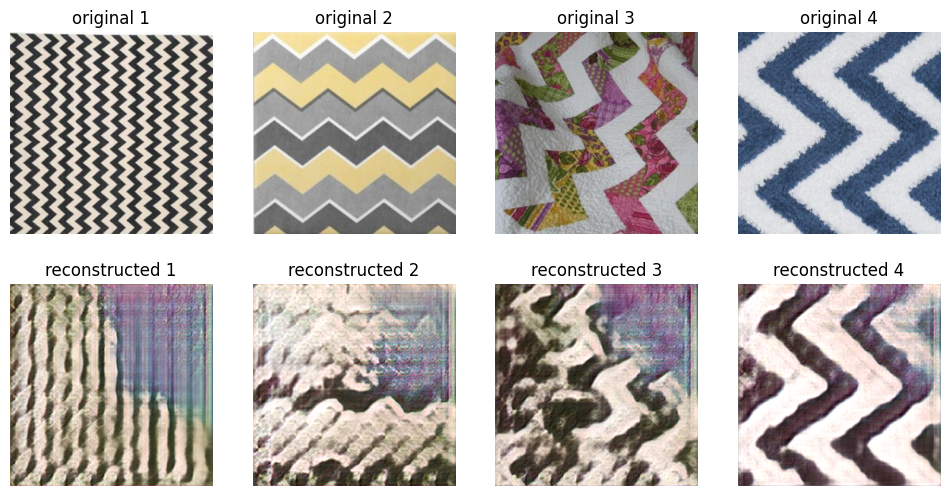

epoch 19


In [25]:
epoch_save_path = os.path.join(save_path, f"epoch_19", "generator", "main_model.pth")
model = VQGAN().to(device)
model.load_state_dict(torch.load(epoch_save_path, weights_only=True))
visual_validation(model, val_loader, device)
print('epoch 19')